# Анализ данных

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки отображения
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


## Загрузка файла

In [32]:
# Загрузка данных
file_path = "drive/MyDrive/new_full_data.xlsx"
df = pd.read_excel(file_path, sheet_name="TDSheet")

# Первые строки
df.head()

,Турнир,ИгрокФИО,Амплуа,Команда,Матч,Данные,КоличествоДействий
0,Молодежное первенство,Морозов Александр,ST,Локомотив Москва-М,Урал-М 1 : 0 Локомотив Москва-М (07.03.2025),Открывание,5
1,Молодежное первенство,Морозов Александр,ST,Локомотив Москва-М,Урал-М 1 : 0 Локомотив Москва-М (07.03.2025),"Эффективность ""-"" Подбора мяча",1
2,Молодежное первенство,Морозов Александр,ST,Локомотив Москва-М,Урал-М 1 : 0 Локомотив Москва-М (07.03.2025),Единоборство вверху в атаке неудачное,2
3,Молодежное первенство,Морозов Александр,ST,Локомотив Москва-М,Урал-М 1 : 0 Локомотив Москва-М (07.03.2025),Передача прогрессивная точная,3
4,Молодежное первенство,Морозов Александр,ST,Локомотив Москва-М,Урал-М 1 : 0 Локомотив Москва-М (07.03.2025),"Эффективность ""+"" Подбора мяча",3


## Общая информация

In [33]:
print("Размер данных:", df.shape)
df.info()

print("\nПропущенные значения:")
print(df.isnull().sum())

Размер данных: (61692, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61692 entries, 0 to 61691
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Турнир              61692 non-null  object
 1   ИгрокФИО            61692 non-null  object
 2   Амплуа              61692 non-null  object
 3   Команда             61692 non-null  object
 4   Матч                61692 non-null  object
 5   Данные              61692 non-null  object
 6   КоличествоДействий  61692 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 3.3+ MB

Пропущенные значения:
Турнир                0
ИгрокФИО              0
Амплуа                0
Команда               0
Матч                  0
Данные                0
КоличествоДействий    0
dtype: int64


##  Обзор уникальных значений и сущностей

In [34]:
summary = {
    "Число записей": len(df),
    "Уникальных игроков": df["ИгрокФИО"].nunique(),
    "Уникальных матчей": df["Матч"].nunique(),
    "Уникальных команд": df["Команда"].nunique(),
    "Уникальных типов действий": df["Данные"].nunique(),
    "Позиции на поле (амплуа)": df["Амплуа"].unique().tolist(),
    "Уникальных турниров": df["Турнир"].nunique()
}
summary

{'Число записей': 61692,
 'Уникальных игроков': 1193,
 'Уникальных матчей': 84,
 'Уникальных команд': 64,
 'Уникальных типов действий': 102,
 'Позиции на поле (амплуа)': ['ST', 'CD', 'AM', 'DM', 'W', 'FB', 'GK'],
 'Уникальных турниров': 4}

##  Топ-10 игроков по активности (по количеству действий)

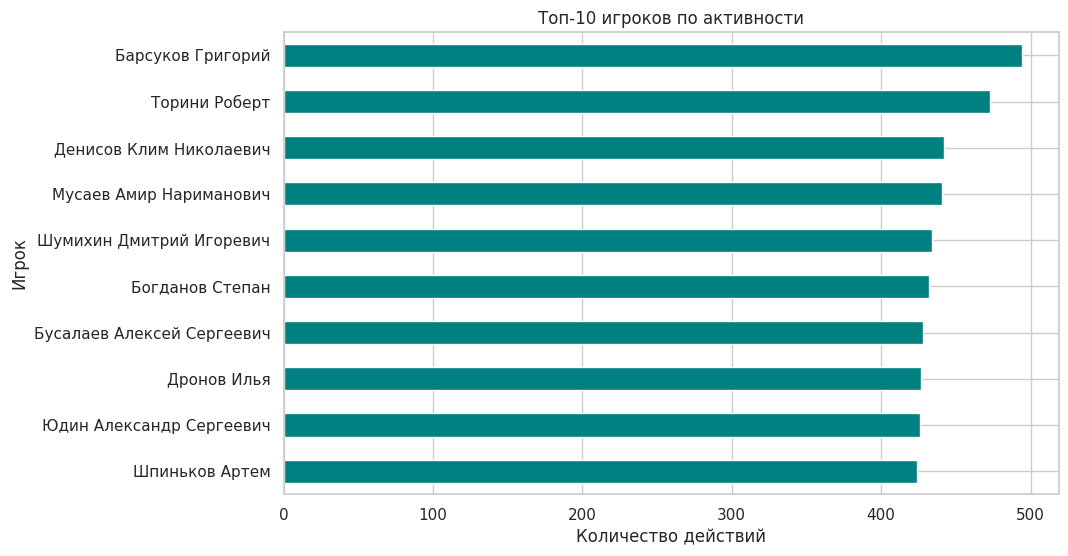

In [35]:
top_players = df.groupby("ИгрокФИО")["КоличествоДействий"].sum().sort_values(ascending=False).head(10)
top_players.plot(kind="barh", figsize=(10, 6), color="teal")
plt.gca().invert_yaxis()
plt.title("Топ-10 игроков по активности")
plt.xlabel("Количество действий")
plt.ylabel("Игрок")
plt.show()


## Частотность игровых действий (топ-15)

<ipython-input-36-6f234c87bd3c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_actions.index, x=top_actions.values, palette="viridis")


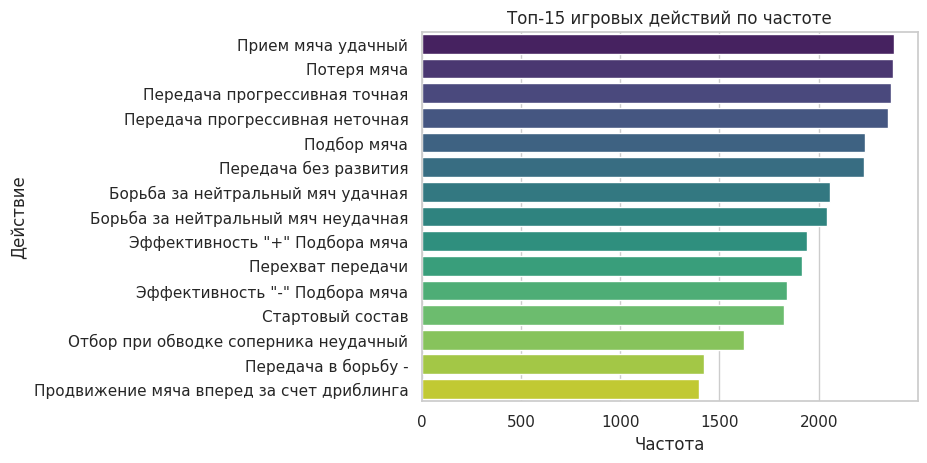

In [36]:
top_actions = df["Данные"].value_counts().head(15)
sns.barplot(y=top_actions.index, x=top_actions.values, palette="viridis")
plt.title("Топ-15 игровых действий по частоте")
plt.xlabel("Частота")
plt.ylabel("Действие")
plt.show()


## Сравнение действий по амплуа (позициям)

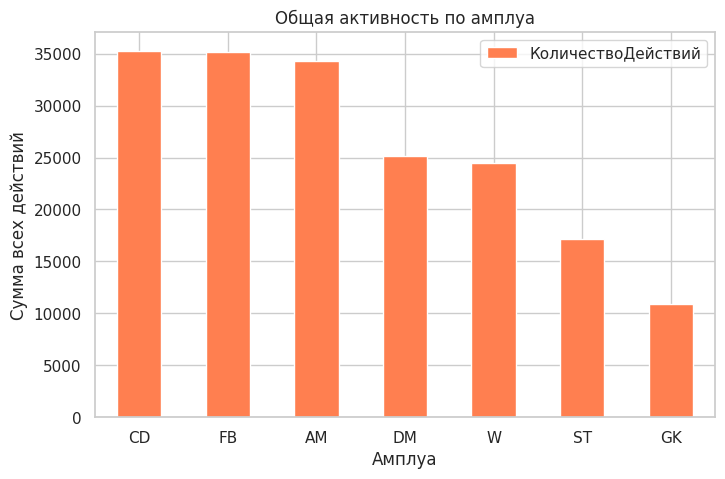

In [37]:
pivot_amplua = df.pivot_table(index="Амплуа", values="КоличествоДействий", aggfunc="sum").sort_values("КоличествоДействий", ascending=False)
pivot_amplua.plot(kind="bar", figsize=(8, 5), color="coral")
plt.title("Общая активность по амплуа")
plt.ylabel("Сумма всех действий")
plt.xlabel("Амплуа")
plt.xticks(rotation=0)
plt.show()

## Тепловая карта: 10 популярных действий против амплуа

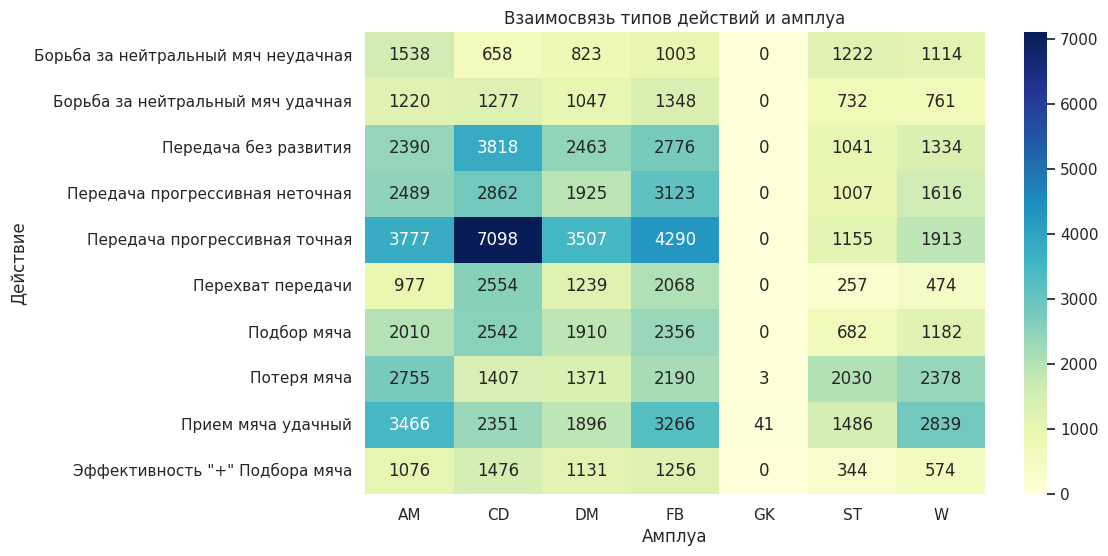

In [38]:
top10_actions = df["Данные"].value_counts().head(10).index
heatmap_data = df[df["Данные"].isin(top10_actions)].pivot_table(
    index="Данные", columns="Амплуа", values="КоличествоДействий", aggfunc="sum", fill_value=0
)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Взаимосвязь типов действий и амплуа")
plt.xlabel("Амплуа")
plt.ylabel("Действие")
plt.show()


## Кластеризация игроков по игровому профилю

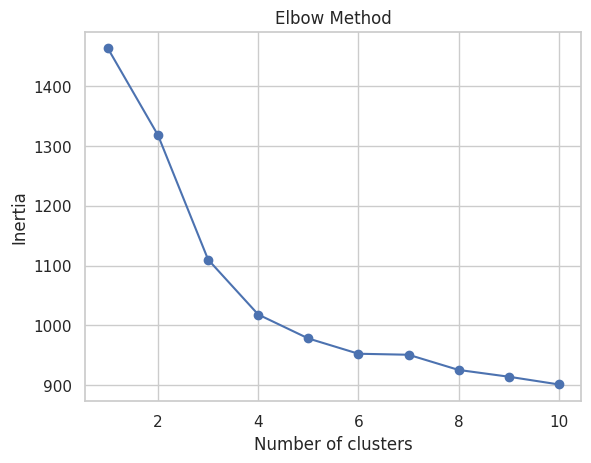

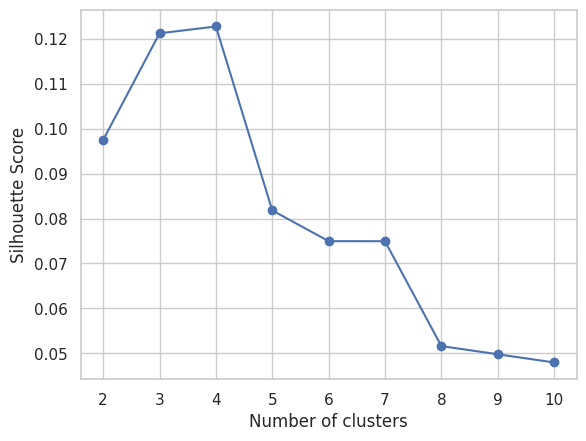

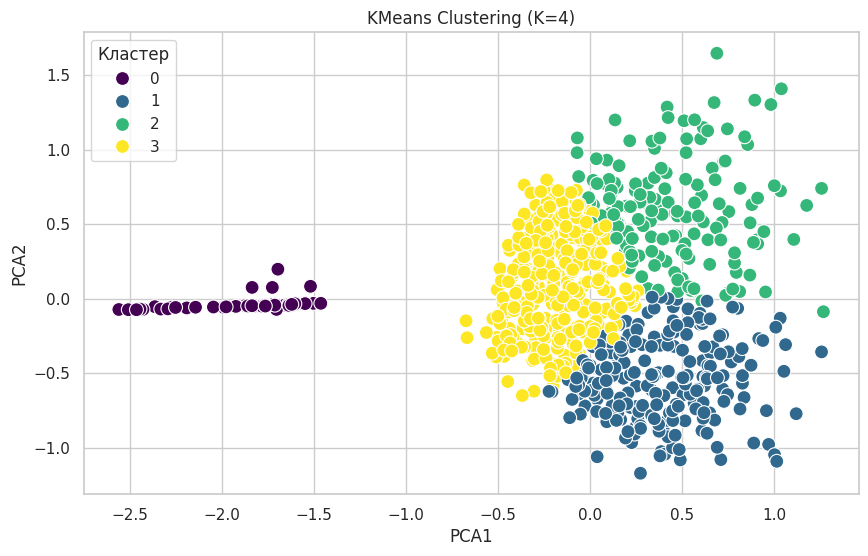

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Создание матрицы игрок-действие
matrix = df.pivot_table(index='ИгрокФИО', columns='Данные', values='КоличествоДействий', aggfunc='sum', fill_value=0)
filtered = matrix[matrix.sum(axis=1) > 100]  # Фильтрация
scaled = MinMaxScaler().fit_transform(filtered)

# Метод локтя для выбора числа кластеров
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Оптимальное число кластеров
best_k = 4

from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled)
    silhouette_scores.append(silhouette_score(scaled, labels))

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Кластеризация KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(scaled)

# Визуализация через PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled)
cluster_df = pd.DataFrame(reduced, columns=["PCA1", "PCA2"])
cluster_df["ИгрокФИО"] = filtered.index
cluster_df["Кластер"] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x="PCA1", y="PCA2", hue="Кластер", palette="viridis", s=100)
plt.title(f"KMeans Clustering (K={best_k})")
plt.show()

## Радарные графики для 3 топ-игроков

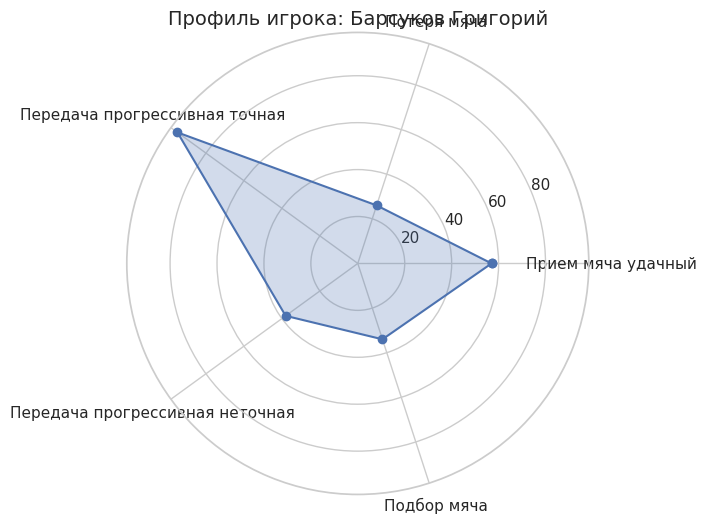

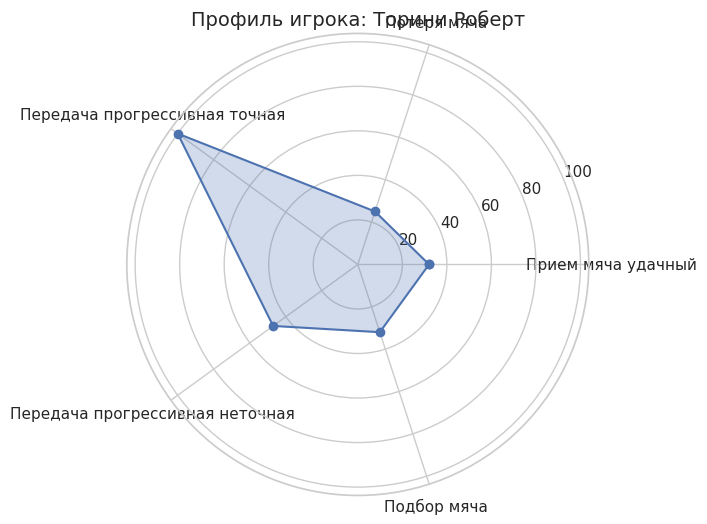

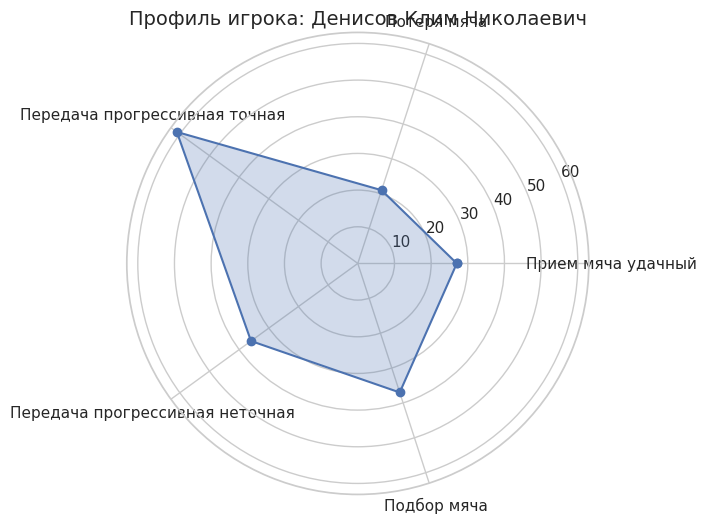

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Выбор 3 топ-игроков
top3 = df.groupby("ИгрокФИО")["КоличествоДействий"].sum().sort_values(ascending=False).head(3).index.tolist()
actions = df["Данные"].value_counts().head(5).index.tolist()  # 5 наиболее часто встречающихся действий

for player in top3:
    player_data = df[df["ИгрокФИО"] == player]
    values = [player_data[player_data["Данные"] == a]["КоличествоДействий"].sum() for a in actions]

    # Радарный график
    angles = np.linspace(0, 2 * np.pi, len(actions), endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, values, marker='o')
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(f"Профиль игрока: {player}", size=14)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(actions)
    plt.show()


## Сравнение активности команд

<ipython-input-28-aa0a7c2cab85>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_activity.values, y=team_activity.index, palette="coolwarm")


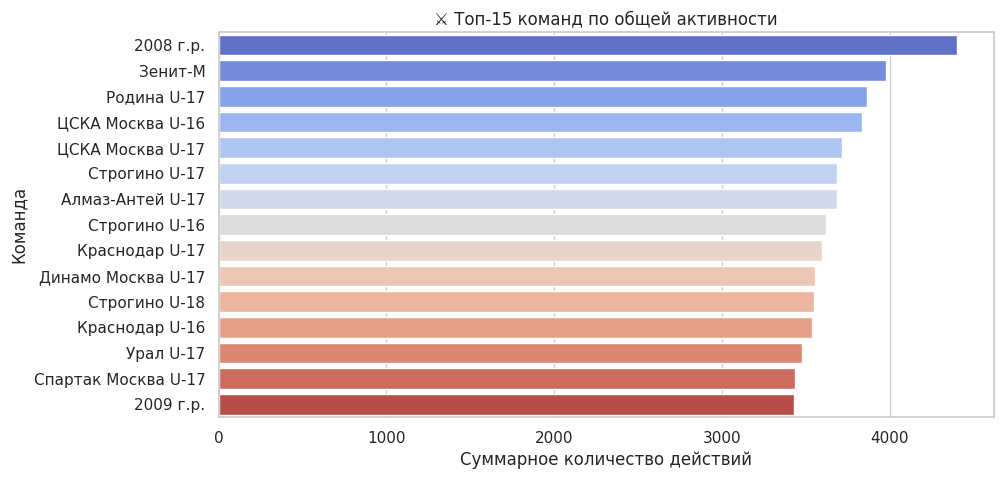

In [28]:
team_activity = df.groupby("Команда")["КоличествоДействий"].sum().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,5))
sns.barplot(x=team_activity.values, y=team_activity.index, palette="coolwarm")
plt.title("Топ-15 команд по общей активности")
plt.xlabel("Суммарное количество действий")
plt.show()


## Активность по турнирам

<ipython-input-30-8c22495359db>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tournament_activity.values, y=tournament_activity.index, palette="magma")


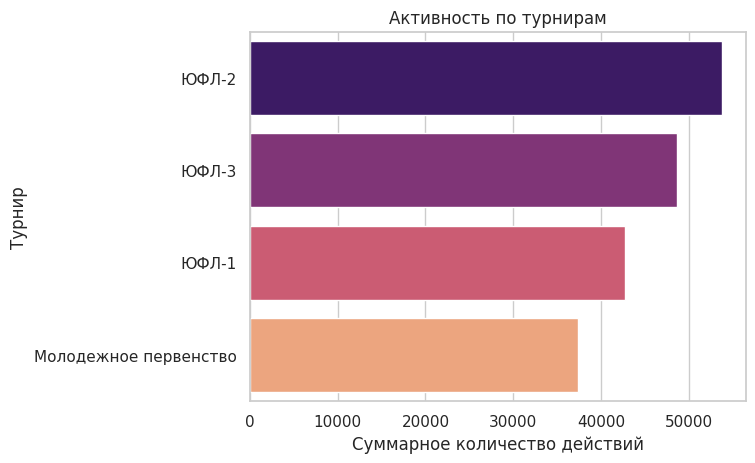

In [30]:
tournament_activity = df.groupby("Турнир")["КоличествоДействий"].sum().sort_values(ascending=False)
sns.barplot(x=tournament_activity.values, y=tournament_activity.index, palette="magma")
plt.title("Активность по турнирам")
plt.xlabel("Суммарное количество действий")
plt.show()
